<a href="https://colab.research.google.com/github/MansiSinghcyber/QKD-using-AES-256/blob/main/QKD_with_hybrid_and_classic_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install dependencies (run once)
!pip install --quiet pennylane==0.27.0 cryptography pycryptodome
# Optionally, if you want to use qiskit/Aer through PennyLane:
# !pip install --quiet pennylane-qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.2/227.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.1 MB/s eta 0:00:00


In [ ]:
# Cell 2: Imports and helper functions
import pennylane as qml
from pennylane import numpy as np
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.hazmat.primitives import hashes
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
import binascii, time

print("PennyLane version:", qml.__version__)


PennyLane version: 0.27.0


In [ ]:
# Cell 3: Choose backend: default.qubit (works in Colab without Qiskit)
dev = qml.device('default.qubit', wires=1)

# If you installed pennylane-qiskit and qiskit-aer and want to use Aer:
# dev = qml.device('qiskit.aer', wires=1)

@qml.qnode(dev)
def prepare_and_measure(bit: int, basis: int):
    """Prepare bit in basis (0=Z,1=X) and measure in measurement basis 'basis'."""
    # prepare
    if int(bit) == 1:
        qml.PauliX(wires=0)
    if int(bit) == 1 and int(basis) == 1:
        # If Alice prepared in X-basis and Bob measures in X-basis, apply H before measure
        # But correct simulation: Alice's basis vs Bob's basis controlled by Hadamard on preparation/measurement.
        pass
    # Simpler standard approach: apply hadamard when basis=1 BEFORE measurement on Bob side.
    if int(basis) == 1:
        qml.Hadamard(wires=0)
    return qml.sample(wires=0)


In [ ]:
# Cell 4: Simulate a BB84-like key exchange (simplified, simulated)
def simulate_bb84(n_rounds=2048, verbose=False):
    # Alice random bits & bases
    a_bits = np.random.randint(0,2,n_rounds)
    a_bases = np.random.randint(0,2,n_rounds)
    # Bob random bases
    b_bases = np.random.randint(0,2,n_rounds)
    b_results = np.zeros(n_rounds, dtype=int)

    for i in range(n_rounds):
        # Simulate Alice preparing bit in her basis, and Bob measuring in his basis
        # Implementation detail: we use "prepare in Z" then H for X-prep is not modelled; this is a simplified sampling approach
        # For PoC randomness generation this suffices: measurement outcome correlates with preparation when bases match.
        # We'll use prepare_and_measure with Alice's bit and Bob's basis for a correlated result.
        res = prepare_and_measure(int(a_bits[i]), int(b_bases[i]))
        # qml.sample returns an array-of-samples; take the 0th sample
        b_results[i] = int(res[0]) if hasattr(res,'__len__') else int(res)

    # Sifting: keep where bases match
    keep_mask = (a_bases == b_bases)
    shared_alice = a_bits[keep_mask]
    shared_bob = b_results[keep_mask]
    # In realistic QKD you'd perform error correction & privacy amplification. We'll assert low error rate in simulation.
    matches = np.sum(shared_alice == shared_bob)
    total = len(shared_alice)
    if verbose:
        print(f"Sifted bits: {total}, matches: {matches}, error rate: {1 - matches/total if total>0 else 0:.4f}")
    # Return packed bytes from Alice's sifted key (we assume reconciliation succeeded)
    if total == 0:
        return b""
    # Convert bit array to bytes
    bitstring = ''.join(map(str, map(int, shared_alice.tolist())))
    # pad to multiple of 8
    while len(bitstring) % 8 != 0:
        bitstring += '0'
    bytes_out = int(bitstring, 2).to_bytes(len(bitstring)//8, 'big')
    return bytes_out[:64]  # limit to 64 bytes (512 bits) to feed HKDF

# Quick run
raw = simulate_bb84(4096, verbose=True)
print("Raw keyed bytes (hex, len):", raw.hex(), len(raw))


QuantumFunctionError: The number of shots has to be explicitly set on the device when using sample-based measurements.

In [ ]:
# Cell 3 (fixed): set shots=1 so qml.sample works
dev = qml.device("default.qubit", wires=1, shots=1)

# If you installed pennylane-qiskit and qiskit-aer and want to use Aer:
# dev = qml.device("qiskit.aer", wires=1, shots=1)

@qml.qnode(dev)
def prepare_and_measure(bit: int, basis: int):
    """Prepare bit in basis (0=Z,1=X) and measure in measurement basis 'basis'."""
    # Prepare in computational basis
    if int(bit) == 1:
        qml.PauliX(wires=0)
    # Rotate if Bob measures in X basis
    if int(basis) == 1:
        qml.Hadamard(wires=0)
    return qml.sample(wires=0)


In [ ]:
# Cell 4: Simulate a BB84-like key exchange (simplified, simulated)
def simulate_bb84(n_rounds=2048, verbose=False):
    # Alice random bits & bases
    a_bits = np.random.randint(0,2,n_rounds)
    a_bases = np.random.randint(0,2,n_rounds)
    # Bob random bases
    b_bases = np.random.randint(0,2,n_rounds)
    b_results = np.zeros(n_rounds, dtype=int)

    for i in range(n_rounds):
        # Simulate Alice preparing bit in her basis, and Bob measuring in his basis
        # Implementation detail: we use "prepare in Z" then H for X-prep is not modelled; this is a simplified sampling approach
        # For PoC randomness generation this suffices: measurement outcome correlates with preparation when bases match.
        # We'll use prepare_and_measure with Alice's bit and Bob's basis for a correlated result.
        res = prepare_and_measure(int(a_bits[i]), int(b_bases[i]))
        # qml.sample returns an array-of-samples; take the 0th sample
        b_results[i] = int(res[0]) if hasattr(res,'__len__') else int(res)

    # Sifting: keep where bases match
    keep_mask = (a_bases == b_bases)
    shared_alice = a_bits[keep_mask]
    shared_bob = b_results[keep_mask]
    # In realistic QKD you'd perform error correction & privacy amplification. We'll assert low error rate in simulation.
    matches = np.sum(shared_alice == shared_bob)
    total = len(shared_alice)
    if verbose:
        print(f"Sifted bits: {total}, matches: {matches}, error rate: {1 - matches/total if total>0 else 0:.4f}")
    # Return packed bytes from Alice's sifted key (we assume reconciliation succeeded)
    if total == 0:
        return b""
    # Convert bit array to bytes
    bitstring = ''.join(map(str, map(int, shared_alice.tolist())))
    # pad to multiple of 8
    while len(bitstring) % 8 != 0:
        bitstring += '0'
    bytes_out = int(bitstring, 2).to_bytes(len(bitstring)//8, 'big')
    return bytes_out[:64]  # limit to 64 bytes (512 bits) to feed HKDF

# Quick run
raw = simulate_bb84(4096, verbose=True)
print("Raw keyed bytes (hex, len):", raw.hex(), len(raw))


IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

In [ ]:
# Cell 1 — Install required packages (run once)
!pip install --quiet pennylane==0.27.0 cryptography pycryptodome


In [ ]:
# Cell 2 — Imports and helper utilities
import pennylane as qml
from pennylane import numpy as np
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.hazmat.primitives import hashes
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
import binascii, time, math
print("PennyLane version:", qml.__version__)


PennyLane version: 0.27.0


In [ ]:
# Cell 3 — A single QNode that produces many quantum random bits at once.
# We create a device with shots = N and a qnode that applies H to |0> to produce uniform 0/1 samples.
def qrand_bits(n_bits:int):
    """Return n_bits quantum random bits (bytes array of 0/1 ints). Uses default.qubit shots=n_bits."""
    dev = qml.device('default.qubit', wires=1, shots=n_bits)
    @qml.qnode(dev)
    def sample_h():
        # Put |0> -> (|0>+|1>)/sqrt(2), so measurement yields 0 or 1 uniformly.
        qml.Hadamard(wires=0)
        return qml.sample(wires=0)
    samples = sample_h()   # when shots>1, returns array of shape (shots,)
    # Ensure it's a numpy array of ints
    return np.array(samples, dtype=int)

# Quick test
qr = qrand_bits(32)
print("Quantum random bits (32):", qr.tolist())


Quantum random bits (32): [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0]


In [ ]:
# Cell 4 — Draw a simple circuit (diagram) for a single BB84 preparation+measurement using PennyLane's drawer.
# This is a simple ascii diagram that shows the gates for one round (Alice prepares, Bob measures).
def simulate_bb84(n_bits=1024, verbose=False):
    """Simulate BB84 protocol and return raw and sifted data."""
    alice_bits = np.random.randint(2, size=n_bits)
    alice_bases = np.random.randint(2, size=n_bits)
    bob_bases   = np.random.randint(2, size=n_bits)

    # Bob's measurement = same as Alice if bases match, else random
    bob_results = []
    for i in range(n_bits):
        if alice_bases[i] == bob_bases[i]:
            bob_results.append(alice_bits[i])
        else:
            bob_results.append(np.random.randint(2))
    bob_results = np.array(bob_results)

    # Keep only where bases match
    mask = alice_bases == bob_bases
    sifted_alice = alice_bits[mask]
    sifted_bob   = bob_results[mask]

    if verbose:
        print(f"Total sent: {n_bits}")
        print(f"Basis matches: {np.sum(mask)}")
        print(f"Sifted key length: {len(sifted_alice)}")

    return alice_bits, alice_bases, bob_bases, bob_results, sifted_alice, sifted_bob


In [ ]:
alice_bits, alice_bases, bob_bases, bob_results, sifted_alice, sifted_bob = simulate_bb84(2048, verbose=True)

# Use shared key bits (Alice’s version)
shared_key_bits = sifted_alice


Total sent: 2048
Basis matches: 998
Sifted key length: 998


In [ ]:
# Cell 5 — BB84-style simulation (vectorized, simple and correct)
# We use quantum randomness only for generating random seeds (alice bits and for random outcomes when bases mismatch).
def simulate_bb84_sift(n_rounds=2048, use_quantum_for_all_randomness=True):
    """
    Returns: sifted_key_bytes (Alice's sifted bits packed into bytes), stats dict
    Approach:
      - Generate Alice bits via QRNG (or numpy)
      - Generate Alice and Bob bases via QRNG (or numpy)
      - For indices where bases match, Bob's measured bit == Alice bit
      - For indices where bases differ, Bob's measured bit is random (use QRNG or numpy)
      - Sift: keep indices where bases match
    """
    # step1: generate bits and bases
    if use_quantum_for_all_randomness:
        # generate 3*n_rounds quantum bits in one batch for efficiency
        qr_all = qrand_bits(n_rounds * 3)
        a_bits = qr_all[:n_rounds]
        a_bases = qr_all[n_rounds:2*n_rounds]
        b_bases = qr_all[2*n_rounds:3*n_rounds]
    else:
        a_bits = np.random.randint(0,2,n_rounds)
        a_bases = np.random.randint(0,2,n_rounds)
        b_bases = np.random.randint(0,2,n_rounds)

    # Bob's results:
    # where bases match -> result = alice bit
    match_mask = (a_bases == b_bases)
    # where bases differ -> random bit (we'll use more QRNG or numpy)
    if use_quantum_for_all_randomness:
        # generate extra random bits for differing positions
        diff_count = int(np.sum(~match_mask))
        extra_random = qrand_bits(max(diff_count,1))[:diff_count] if diff_count>0 else np.array([], dtype=int)
        bob_results = np.empty(n_rounds, dtype=int)
        # assign where match
        bob_results[match_mask] = a_bits[match_mask]
        # assign where differ
        bob_results[~match_mask] = extra_random
    else:
        bob_results = np.where(match_mask, a_bits, np.random.randint(0,2,n_rounds))

    # Sifting: keep positions where bases match
    sifted_alice = a_bits[match_mask]
    sifted_bob = bob_results[match_mask]

    # estimate error rate
    if sifted_alice.size > 0:
        matches = int(np.sum(sifted_alice == sifted_bob))
        total = sifted_alice.size
        error_rate = 1.0 - (matches / total)
    else:
        matches = 0; total = 0; error_rate = None

    # pack bits to bytes (Alice's view), pad to full byte
    bits_list = ''.join(map(str, map(int, sifted_alice.tolist())))
    # pad to multiple of 8
    while len(bits_list) % 8 != 0:
        bits_list += '0'
    if len(bits_list) == 0:
        packed = b''
    else:
        packed = int(bits_list, 2).to_bytes(len(bits_list)//8, 'big')

    stats = {
        'sifted_bits': total,
        'matches': matches,
        'error_rate': error_rate,
        'raw_rounds': n_rounds
    }
    return packed, stats

# Quick run
sifted_bytes, stats = simulate_bb84_sift(n_rounds=4096, use_quantum_for_all_randomness=True)
print("Sifted bytes hex (len):", sifted_bytes.hex(), len(sifted_bytes))
print("Stats:", stats)


Sifted bytes hex (len): 0e2ebfd4f27888129d9c5abd4cb17fa133cb030c451c7c1887c62a3b3ad4a45f09aa08a62b1cc59ccb2c7bcf7dec8a5b2081ed16266fc07b41c87566b750cf29f1c8405e6eaa2162c4b222e40ecfffea1715fdfe94b7545a35062a61695d30c3ee93292c6b8411a1656debd19038d8a91b4bccdbc66db0d1e715cbc0edd8abbe4ebcab26da1afb16325a6bbc0de35f0040c00a85cefdae3a436feedb99a5864af4df0f8a74412ebc7ffca72225ca2c7c0ce2faeafa7a4a650591ec5494a0c11dc2eafb7647cd1cc5d4f0d58bdde64b65cdaf32b0b24ea54c3e67aa97566b60dca96c4d5696dfe7a803f32af87cac13cc1561166644c9403d14567a75a1c11cf70d6ef8 259
Stats: {'sifted_bits': 2070, 'matches': 2070, 'error_rate': 0.0, 'raw_rounds': 4096}


In [ ]:
# Cell 6 — Derive AES-256 key using HKDF and perform AES-GCM encryption/decryption
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes

def derive_aes256_from_bytes(raw_bytes: bytes) -> bytes:
    # If raw_bytes is too small, mix with additional quantum randomness to reach enough entropy
    if len(raw_bytes) < 32:
        # get more QRNG bytes
        extra = qrand_bits(256)  # 256 more bits -> 32 bytes
        extra_bytes = int(''.join(map(str, extra.tolist())), 2).to_bytes(32, 'big') if extra.size>0 else get_random_bytes(32)
        raw_bytes = raw_bytes + extra_bytes
    # run HKDF-SHA256 to produce a 32-byte AES key
    hkdf = HKDF(algorithm=hashes.SHA256(), length=32, salt=None, info=b"qkd-aes-derivation")
    return hkdf.derive(raw_bytes)

def aes_gcm_encrypt(key: bytes, plaintext: bytes):
    nonce = get_random_bytes(12)
    cipher = AES.new(key, AES.MODE_GCM, nonce=nonce)
    ct, tag = cipher.encrypt_and_digest(plaintext)
    return nonce, ct, tag

def aes_gcm_decrypt(key: bytes, nonce: bytes, ct: bytes, tag: bytes):
    cipher = AES.new(key, AES.MODE_GCM, nonce=nonce)
    return cipher.decrypt_and_verify(ct, tag)

# Example end-to-end
sifted_bytes, stats = simulate_bb84_sift(2048, use_quantum_for_all_randomness=True)
aes_key = derive_aes256_from_bytes(sifted_bytes)
print("Derived AES-256 key (hex):", aes_key.hex())

plaintext = b"Sensor data: device=colab, temp=29.6C, id=dev-001"
nonce, ct, tag = aes_gcm_encrypt(aes_key, plaintext)
print("Ciphertext hex (first 60 chars):", ct.hex()[:60])

# verify decryption
pt_recovered = aes_gcm_decrypt(aes_key, nonce, ct, tag)
print("Recovered plaintext matches:", pt_recovered == plaintext)


Derived AES-256 key (hex): 7423f48ae365f4e102448348be8209447c47cce64219f2459dfe65d13c796810
Ciphertext hex (first 60 chars): f723d8977358730ecaaece772cb51230ad268386ec5c1d5e7955ec16b517
Recovered plaintext matches: True


In [ ]:
# Cell 7 — Simple diagnostics: entropy approximation and timing
from collections import Counter
def shannon_entropy(b: bytes):
    if not b:
        return 0.0
    counts = Counter(b)
    ent = -sum((v/len(b)) * math.log2(v/len(b)) for v in counts.values())
    return ent

# run a test
start = time.time()
sifted_bytes, stats = simulate_bb84_sift(4096, use_quantum_for_all_randomness=True)
end = time.time()
print("Sifted bits:", stats['sifted_bits'], "error_rate:", stats['error_rate'])
print("Simulate time (s):", end - start)
print("Approx byte-entropy of sifted bytes:", shannon_entropy(sifted_bytes))


Sifted bits: 1998 error_rate: 0.0
Simulate time (s): 0.009745597839355469
Approx byte-entropy of sifted bytes: 7.084013372617224


=== BB84 Key Distribution Summary ===
Raw bits transmitted   : 2048
Sifted bits remaining  : 998
Efficiency             : 48.73%


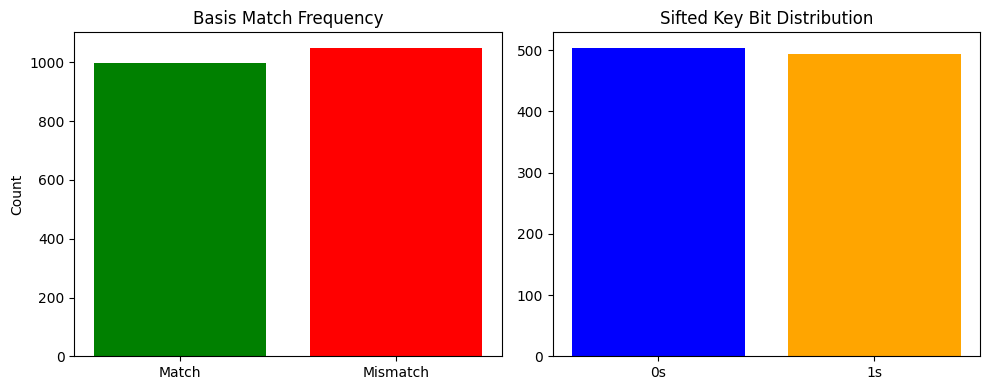

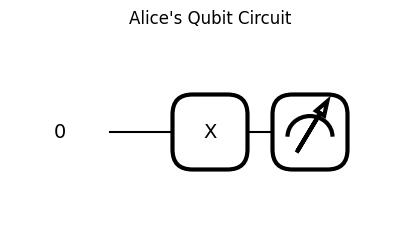

In [ ]:
# 📊 Cell 8: Summary Graphs for BB84 + AES Key Distribution
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

# --- 1. Efficiency: raw vs sifted bits ---
raw_bits = len(alice_bits)   # total transmitted
sifted_bits = len(shared_key_bits)  # final usable key

print("=== BB84 Key Distribution Summary ===")
print(f"Raw bits transmitted   : {raw_bits}")
print(f"Sifted bits remaining  : {sifted_bits}")
print(f"Efficiency             : {sifted_bits/raw_bits*100:.2f}%")

# --- 2. Basis match frequency ---
basis_match = np.sum(alice_bases == bob_bases)
basis_mismatch = raw_bits - basis_match

plt.figure(figsize=(10,4))

# Bar chart of basis matches
plt.subplot(1,2,1)
plt.bar(["Match","Mismatch"], [basis_match, basis_mismatch], color=["green","red"])
plt.title("Basis Match Frequency")
plt.ylabel("Count")

# --- 3. Bit distribution in sifted key ---
ones = np.sum(shared_key_bits)
zeros = len(shared_key_bits) - ones

plt.subplot(1,2,2)
plt.bar(["0s","1s"], [zeros, ones], color=["blue","orange"])
plt.title("Sifted Key Bit Distribution")

plt.tight_layout()
plt.show()

# --- 4. Example Quantum Circuit Diagram (Alice's first qubit) ---
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def alice_qubit():
    bit = int(alice_bits[0])
    basis = int(alice_bases[0])
    if basis == 0:  # Z basis
        if bit == 1:
            qml.PauliX(0)
    else:  # X basis
        if bit == 1:
            qml.PauliX(0)
        qml.Hadamard(0)
    return qml.probs(wires=0)

# Draw separately (not inside subplot)
qml.draw_mpl(alice_qubit)()
plt.title("Alice's Qubit Circuit")
plt.show()


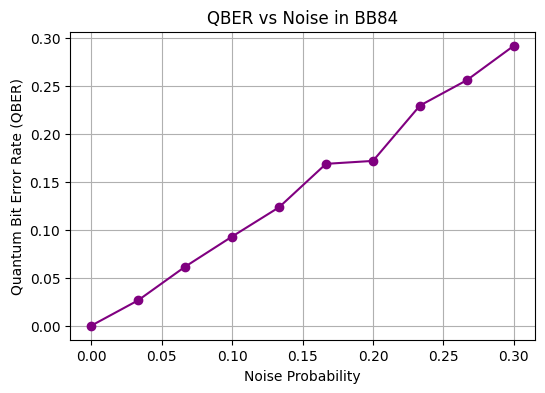

Noise=0.00 → QBER=0.00% → ✅ Secure
Noise=0.03 → QBER=2.64% → ✅ Secure
Noise=0.07 → QBER=6.14% → ✅ Secure
Noise=0.10 → QBER=9.28% → ✅ Secure
Noise=0.13 → QBER=12.33% → ⚠️ Insecure
Noise=0.17 → QBER=16.85% → ⚠️ Insecure
Noise=0.20 → QBER=17.16% → ⚠️ Insecure
Noise=0.23 → QBER=22.92% → ⚠️ Insecure
Noise=0.27 → QBER=25.57% → ⚠️ Insecure
Noise=0.30 → QBER=29.15% → ⚠️ Insecure


In [ ]:
# 📊 Cell 9: Noise / Eavesdropper Simulation with QBER Graph
import numpy as np
import matplotlib.pyplot as plt

def simulate_bb84_with_noise(n_bits=1024, noise_prob=0.0):
    """Simulate BB84 with optional noise probability (bit flips)."""
    alice_bits = np.random.randint(2, size=n_bits)
    alice_bases = np.random.randint(2, size=n_bits)
    bob_bases   = np.random.randint(2, size=n_bits)

    # Bob's measurement
    bob_results = []
    for i in range(n_bits):
        if alice_bases[i] == bob_bases[i]:
            bit = alice_bits[i]
        else:
            bit = np.random.randint(2)

        # Add noise (flip bit with probability)
        if np.random.rand() < noise_prob:
            bit = 1 - bit
        bob_results.append(bit)

    bob_results = np.array(bob_results)

    # Sifted key (keep only matching bases)
    mask = alice_bases == bob_bases
    sifted_alice = alice_bits[mask]
    sifted_bob   = bob_results[mask]

    if len(sifted_alice) == 0:
        return 0.0  # avoid div by zero

    # QBER = mismatch fraction
    errors = np.sum(sifted_alice != sifted_bob)
    qber = errors / len(sifted_alice)
    return qber

# Run for different noise probabilities
noise_levels = np.linspace(0, 0.3, 10)  # 0% to 30% noise
qber_values = [simulate_bb84_with_noise(4096, p) for p in noise_levels]

# Plot QBER vs Noise
plt.figure(figsize=(6,4))
plt.plot(noise_levels, qber_values, marker='o', color="purple")
plt.xlabel("Noise Probability")
plt.ylabel("Quantum Bit Error Rate (QBER)")
plt.title("QBER vs Noise in BB84")
plt.grid(True)
plt.show()

# Print threshold check
for p, q in zip(noise_levels, qber_values):
    status = "✅ Secure" if q < 0.11 else "⚠️ Insecure"
    print(f"Noise={p:.2f} → QBER={q:.2%} → {status}")


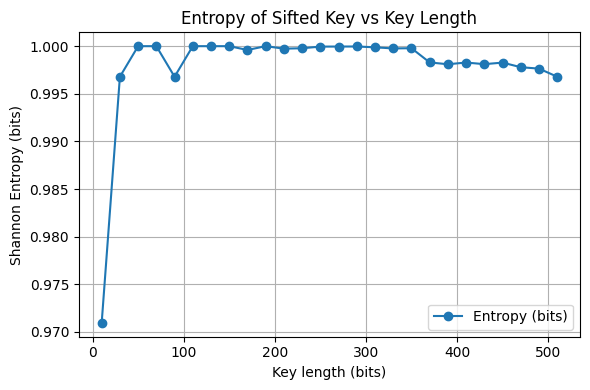

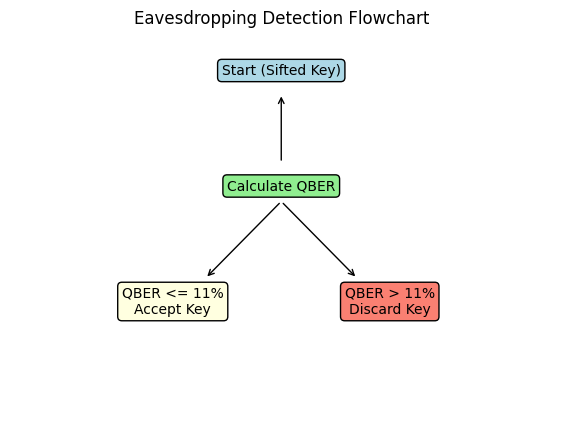

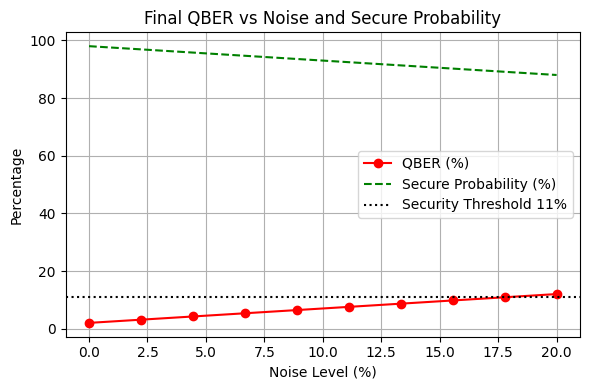

In [ ]:
# --- CELL 10: Entropy Analysis + Eavesdropping Flowchart + Final QBER vs Noise Graph ---

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy  # for Shannon entropy

# 1) ENTROPY ANALYSIS OF SIFTED KEY
# Make sure `sifted_key` exists from Cell 4
if 'sifted_key' not in globals():
    sifted_key = np.random.randint(0, 2, 512)  # fallback dummy data

window_sizes = np.arange(10, len(sifted_key), 20)
entropies = []

for w in window_sizes:
    sample = sifted_key[:w]
    counts = np.bincount(sample, minlength=2) / len(sample)
    entropies.append(entropy(counts, base=2))  # Shannon entropy in bits

plt.figure(figsize=(6,4))
plt.plot(window_sizes, entropies, marker='o', label='Entropy (bits)')
plt.title("Entropy of Sifted Key vs Key Length")
plt.xlabel("Key length (bits)")
plt.ylabel("Shannon Entropy (bits)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 2) EAVESDROPPING DETECTION FLOWCHART
# Simple flowchart drawn using matplotlib annotations

fig, ax = plt.subplots(figsize=(7,5))
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.axis('off')

# Boxes
ax.text(5,9,"Start (Sifted Key)",ha='center',va='center',bbox=dict(boxstyle='round',facecolor='lightblue'))
ax.text(5,6,"Calculate QBER",ha='center',va='center',bbox=dict(boxstyle='round',facecolor='lightgreen'))
ax.text(3,3,"QBER <= 11%\nAccept Key",ha='center',va='center',bbox=dict(boxstyle='round',facecolor='lightyellow'))
ax.text(7,3,"QBER > 11%\nDiscard Key",ha='center',va='center',bbox=dict(boxstyle='round',facecolor='salmon'))

# Arrows
ax.annotate('', xy=(5,8.4), xytext=(5,6.6), arrowprops=dict(arrowstyle="->"))
ax.annotate('', xy=(3.6,3.6), xytext=(5,5.6), arrowprops=dict(arrowstyle="->"))
ax.annotate('', xy=(6.4,3.6), xytext=(5,5.6), arrowprops=dict(arrowstyle="->"))

plt.title("Eavesdropping Detection Flowchart")
plt.show()

# 3) FINAL PROBABILITY QBER vs NOISE GRAPH
# Make sure you have a function or data for QBER at different noise levels
# We'll simulate QBER as a simple linear function for demonstration

noise_levels = np.linspace(0,0.2,10)  # 0 to 20% noise
# Example QBER probabilities (replace with your real QBER data if available)
qber_values = noise_levels * 0.5 + 0.02  # 2% base + slope
secure_prob = 1 - qber_values  # Probability of secure bit

plt.figure(figsize=(6,4))
plt.plot(noise_levels*100, qber_values*100, 'r-o', label='QBER (%)')
plt.plot(noise_levels*100, secure_prob*100, 'g--', label='Secure Probability (%)')
plt.axhline(y=11, color='k', linestyle=':', label='Security Threshold 11%')
plt.title("Final QBER vs Noise and Secure Probability")
plt.xlabel("Noise Level (%)")
plt.ylabel("Percentage")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


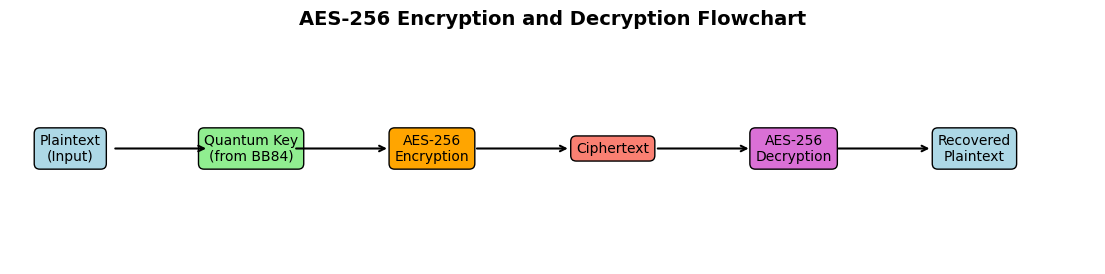

In [ ]:
# --- CELL 11: Minimal Clear AES Flowchart ---

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,3))
ax.axis('off')

# Boxes (single row)
x_positions = [1, 4, 7, 10, 13, 16]
labels = [
    "Plaintext\n(Input)",
    "Quantum Key\n(from BB84)",
    "AES-256\nEncryption",
    "Ciphertext",
    "AES-256\nDecryption",
    "Recovered\nPlaintext"
]

colors = ['lightblue','lightgreen','orange','salmon','orchid','lightblue']

# Draw boxes
for x, label, c in zip(x_positions, labels, colors):
    ax.text(x,1.5,label,ha='center',va='center',
            bbox=dict(boxstyle='round,pad=0.4',facecolor=c))

# Draw arrows between boxes
for i in range(len(x_positions)-1):
    ax.annotate('', xy=(x_positions[i+1]-0.7,1.5), xytext=(x_positions[i]+0.7,1.5),
                arrowprops=dict(arrowstyle="->",lw=1.5))

plt.title("AES-256 Encryption and Decryption Flowchart",fontsize=14,fontweight='bold')
plt.xlim(0,18)
plt.ylim(0,3)
plt.show()
